In [1]:
import sys

sys.path.append("../")

In [2]:
import cv2 as cv
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sulllam.localization.extraction.orb import ORBFeatureExtractor, ORBConfigs
from sulllam.localization.matching.bf import BFMatcherConfig, BFFeatureMatcher
from sulllam.localization.pose_estimation.eight_point_estimator import EightPointEstimatorConfig, EightPointPoseEstimator

Images:

In [4]:
image_dir = Path("/home/zhukowych/Projects/ucu/MMML/SULLLAM/data/itspace")
images = [cv.imread(image_path) for image_path in sorted(image_dir.glob("*.png"))[:200]]

Camera calibration:

In [5]:
K = np.array([[533.34072745,   0.        , 254.64689388],
              [  0.        , 533.25564953, 256.48354909],
              [  0.        ,   0.        ,   1.        ]])

ORB keypoint extractor

In [6]:
orb_config = ORBConfigs()
orb_extrator = ORBFeatureExtractor()

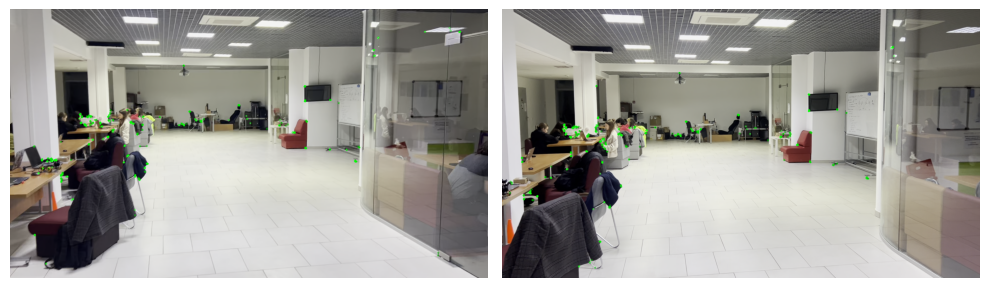

In [29]:
first_image = images[0]
second_image = images[50]

first_image = cv.cvtColor(first_image, cv.COLOR_BGR2RGB)
second_image = cv.cvtColor(second_image, cv.COLOR_BGR2RGB)


img0_keypoints, img0_descriptors = orb_extrator.extract(first_image)
img1_keypoints, img1_descriptors = orb_extrator.extract(second_image)

image_0_with_keypoints = cv.drawKeypoints(first_image, img0_keypoints, 0, (0, 255, 0),
                                 flags=cv.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)
image_1_with_keypoints = cv.drawKeypoints(second_image, img1_keypoints, 0, (0, 255, 0),
                                 flags=cv.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)

cv.imwrite("keypoi.png", cv.cvtColor(image_0_with_keypoints, cv.COLOR_RGB2BGR))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(image_0_with_keypoints)
ax1.axis('off')

ax2.imshow(image_1_with_keypoints)
ax2.axis('off')


plt.tight_layout()
plt.show()

BruteForce Matcher

In [8]:
bf_config = BFMatcherConfig()
bf_matcher = BFFeatureMatcher(config=bf_config)

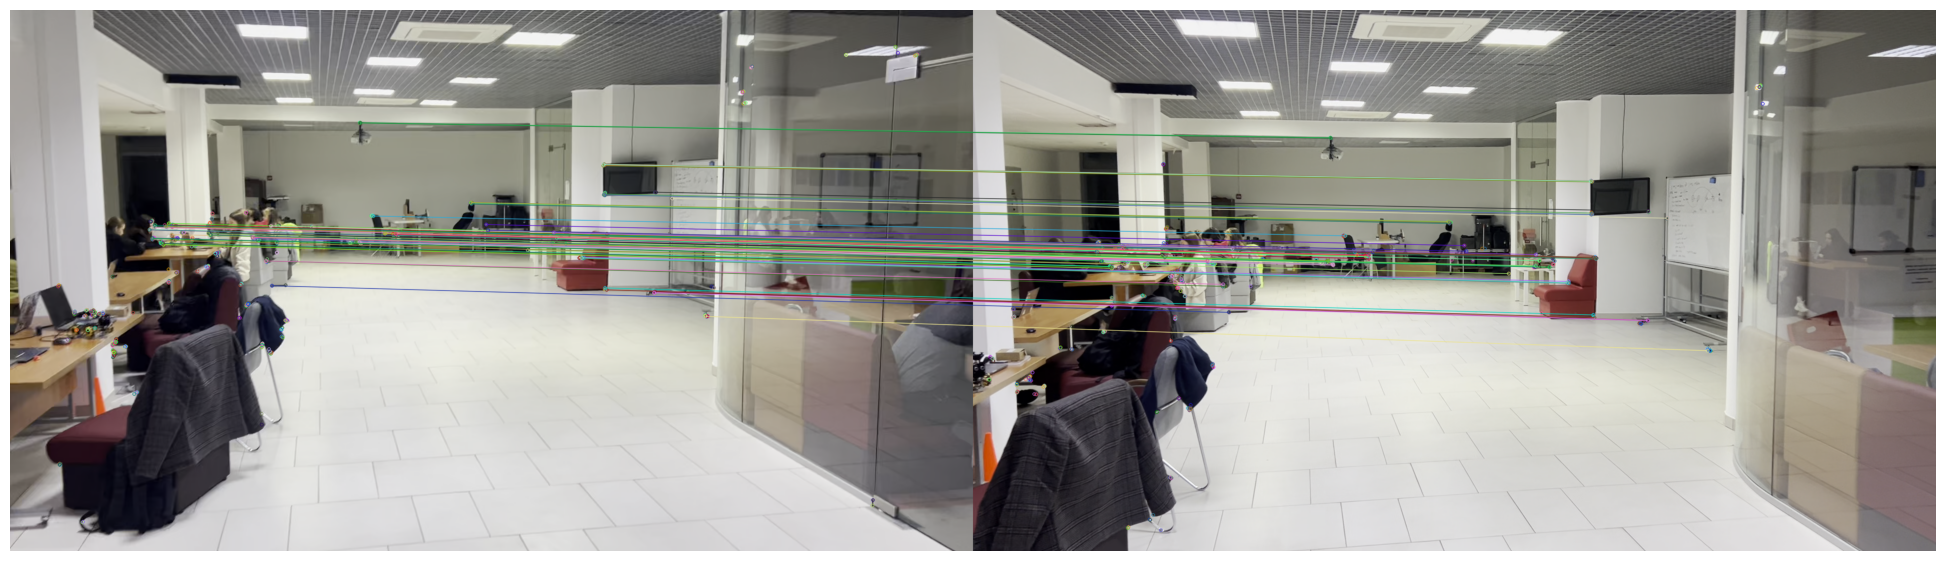

In [24]:
matches = bf_matcher.match(img0_descriptors, img1_descriptors)

images_with_matches = cv.drawMatches(first_image, img0_keypoints, second_image, img1_keypoints, matches, None)

plt.figure(figsize=(20, 10))
plt.imshow(images_with_matches)
plt.tight_layout()
plt.axis('off')
plt.show()

In [33]:
import cv2 as cv
import numpy as np

def draw_matches_vertically(img1, kp1, img2, kp2, matches):
    """
    Draws feature matches vertically, with img1 on top of img2.
    """
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # 1. Pad images if their widths don't match
    max_width = max(w1, w2)
    
    # If images are grayscale, convert to BGR so we can draw colored lines
    if len(img1.shape) == 2:
        img1 = cv.cvtColor(img1, cv.COLOR_GRAY2BGR)
    if len(img2.shape) == 2:
        img2 = cv.cvtColor(img2, cv.COLOR_GRAY2BGR)

    img1_padded = cv.copyMakeBorder(img1, 0, 0, 0, max_width - w1, cv.BORDER_CONSTANT, value=[0, 0, 0])
    img2_padded = cv.copyMakeBorder(img2, 0, 0, 0, max_width - w2, cv.BORDER_CONSTANT, value=[0, 0, 0])

    # 2. Stack the images vertically
    stacked_img = np.vstack((img1_padded, img2_padded))

    # 3. Draw the lines and keypoints
    for match in matches:
        # Get the matching keypoints for each of the images
        pt1 = kp1[match.queryIdx].pt
        pt2 = kp2[match.trainIdx].pt

        # Convert coordinates to integers
        pt1 = (int(pt1[0]), int(pt1[1]))
        
        # Shift the Y-coordinate of the second point down by the height of the first image
        pt2 = (int(pt2[0]), int(pt2[1] + h1))

        # Generate a random color for each match line (BGR format)
        color = tuple(np.random.randint(0, 255, 3).tolist())

        # Draw circles on keypoints and a line connecting them
        cv.circle(stacked_img, pt1, 4, color, 1)
        cv.circle(stacked_img, pt2, 4, color, 1)
        cv.line(stacked_img, pt1, pt2, color, 1)

    return stacked_img

images_with_matches = draw_matches_vertically(first_image, img0_keypoints, second_image, img1_keypoints, matches)

cv.imwrite("test.png", cv.cvtColor(images_with_matches, cv.COLOR_RGB2BGR))


True

Eightpoint Pose Estimator

In [ ]:
eight_point_config = EightPointEstimatorConfig(K=K)
eight_point_pose_estimator = EightPointPoseEstimator(config=eight_point_config)

In [ ]:
sorted_kps1 = np.array([img0_keypoints[m.queryIdx].pt for m in matches])
sorted_kps2 = np.array([img1_keypoints[m.trainIdx].pt for m in matches])
eight_point_pose_estimator.estimate(sorted_kps1, sorted_kps2)

{'success': True,
 'R': array([[ 0.99998   , -0.00208806, -0.00596917],
        [ 0.00205945,  0.99998638, -0.00479491],
        [ 0.0059791 ,  0.00478252,  0.99997069]]),
 't': array([[-0.05118268],
        [ 0.54223031],
        [ 0.83866956]]),
 'points': 15}

In [ ]:
def visualize_essential_matrix_matches(img1, img2, kp1, kp2, des1, des2, K):
    """
    Matches features, computes the Essential Matrix using RANSAC, 
    and draws inliers (green) and outliers (red).
    """
    
    # 1. Match features (Using Brute Force Matcher for simplicity)
    # Note: If using ORB, use cv2.NORM_HAMMING instead of cv2.NORM_L2
    bf = cv.BFMatcher(cv.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)

    # Extract point coordinates from the matches
    pts1 = np.array([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.array([kp2[m.trainIdx].pt for m in matches])

    # 2. Find the Essential Matrix using RANSAC
    # The function returns the matrix E and a mask (1 for inliers, 0 for outliers)
    E, mask = cv.findEssentialMat(
        pts1, 
        pts2, 
        K, 
        method=cv.RANSAC, 
        prob=0.999,     # Confidence probability
        threshold=1.0   # Distance threshold for a point to be an inlier
    )
    
    # Flatten mask to a standard Python list
    mask = mask.ravel().tolist()

    # 3. Separate matches into inliers and outliers based on the mask
    inlier_matches = []
    outlier_matches = []
    for i, match in enumerate(matches):
        if mask[i] == 1:
            inlier_matches.append(match)
        else:
            outlier_matches.append(match)

    # 4. Draw the matches
    # Draw outliers first in RED
    # Note: OpenCV uses BGR color format, but if plotting with Matplotlib, we need RGB.
    # Below uses RGB colors: Red=(255, 0, 0), Green=(0, 255, 0)
    
    outlier_color = (255, 0, 0) # Red in RGB
    inlier_color = (0, 255, 0)  # Green in RGB

    # Create the base image with outlier matches
    result_img = cv.drawMatches(
        img1, kp1, 
        img2, kp2, 
        outlier_matches, 
        None,
        matchColor=outlier_color,
        singlePointColor=outlier_color,
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Draw inlier matches ON TOP of the existing image
    result_img = cv.drawMatches(
        img1, kp1, 
        img2, kp2, 
        inlier_matches, 
        result_img, # Pass the previous image as the output image
        matchColor=inlier_color,
        singlePointColor=inlier_color,
        flags=cv.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # 5. Display the result
    plt.figure(figsize=(20, 10))
    plt.imshow(result_img)
    plt.title(f"Matches: {len(inlier_matches)} Inliers (Green), {len(outlier_matches)} Outliers (Red)")
    plt.axis('off')
    plt.show()

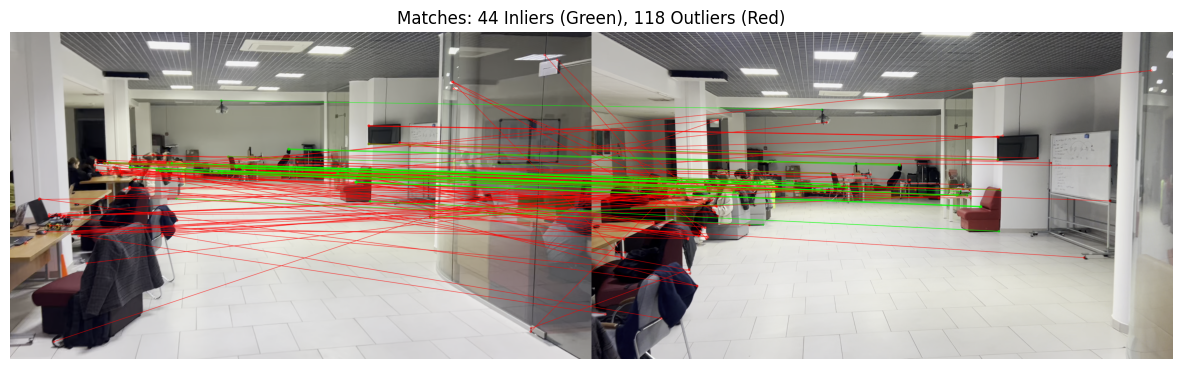

In [21]:
fx = 3100.0
fy = 3100.0
cx = 2016.0
cy = 1512.0

K = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
], dtype=np.float32)

visualize_essential_matrix_matches(first_image, second_image, img0_keypoints, img1_keypoints, img0_descriptors, img1_descriptors, K)